# Universidad de Buenos Aires
## Laboratorio de Sistemas Embebidos
## Especialización en Inteligencia Artificial

**Probabilidad y Estadística para la Inteligencia Artificial**

**Docente:** Camilo Argoty

---

**Nombre:** Franco Marcelo Morero &nbsp;&nbsp;&nbsp; **Código:** a2533

**Fecha:** 15 de Junio de 2026

---

### EXAMEN FINAL

Siguiendo con la historia de Don Francisco, con el tiempo y gracias a los análisis de Matías, el pequeño comerciante de barrio cuenta hoy con 5 supermercados: 'Santa Ana', 'La Floresta', 'Los Cedros', 'Palermo' y 'Córdoba'.

También Matías ha avanzado en la Especialización en Inteligencia Artificial. Un día Don Francisco le plantea algunas inquietudes adicionales:

1. Don Francisco quiere entender mejor la afluencia de clientes por mes del supermercado 'Santa Ana'.
2. Más aún, Don Francisco no sabe si puede estar seguro de que la afluencia de clientes son las mismas en todos los supermercados o si hay alguno que se comporte mejor que los demás, y si alguna de las tiendas necesita más atención porque está recibiendo menos clientes que las de las otras.

---

Cargamos las librerías y fijamos la semilla del generador aleatorio para que la simulación sea reproducible.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

rng = np.random.default_rng(42)

## 1. Simulación del número de clientes diarios

Crear una simulación del número de clientes diarios que van a los almacenes de Don Francisco y de Don Miguel, usando distribuciones Poisson, entre los años 2023, 2024 y 2025. En cada fecha, el parámetro $\lambda_t$ debe ser la suma de los siguientes efectos:

> **Nota.** Se interpreta que la segunda aparición de 2024 en el enunciado corresponde al año 2025, dado que el período solicitado comprende 2023, 2024 y 2025.

**Efecto anual:**

| Año | Efecto |
|:---:|:---:|
| 2023 | 1000 |
| 2024 | 1500 |
| 2025 | 2000 |

**Efecto mensual:**

| Mes | Efecto |
|:---:|:---:|
| Enero | 1000 |
| Febrero | 1500 |
| Marzo | 2000 |
| Abril | 2000 |
| Mayo | 2500 |
| Junio | 2500 |
| Julio | 3000 |
| Agosto | 2500 |
| Septiembre | 2500 |
| Octubre | 2000 |
| Noviembre | 1500 |
| Diciembre | 1000 |

**Efecto diario:**

| Mes | Efecto |
|:---:|:---:|
| Domingo | 1000 |
| Lunes | 2000 |
| Martes | 3000 |
| Miércoles | 3500 |
| Jueves | 3000 |
| Viernes | 2000 |
| Sábado | 1000 |

**Efecto por tienda:**

| Mes | Efecto |
|:---:|:---:|
| Santa Ana | 5000 |
| La Floresta | 2000 |
| Los Cedros | 3000 |
| Palermo | 1000 |
| Córdoba | 3000 |

### Planteo del modelo

Para una fecha $t$ y una tienda $s$, el número de clientes se modela como una variable de Poisson:

$$
N_{t,s} \sim \text{Poisson}(\lambda_{t,s}),
\qquad
\lambda_{t,s} = a_{\text{año}(t)} + m_{\text{mes}(t)} + d_{\text{díaSem}(t)} + e_s .
$$

In [2]:
dias_es = {
    0: 'Lunes', 
    1: 'Martes', 
    2: 'Miércoles', 
    3: 'Jueves',
    4: 'Viernes', 
    5: 'Sábado', 
    6: 'Domingo'
}

meses_es = {
    1: 'Enero', 
    2: 'Febrero', 
    3: 'Marzo', 
    4: 'Abril', 
    5: 'Mayo',
    6: 'Junio', 
    7: 'Julio', 
    8: 'Agosto', 
    9: 'Septiembre',
    10: 'Octubre', 
    11: 'Noviembre', 
    12: 'Diciembre'
}

efecto_anual = {
    2023: 1000, 
    2024: 1500, 
    2025: 2000
}

efecto_mensual = {
    1: 1000, 
    2: 1500,  
    3: 2000,  
    4: 2000,  
    5: 2500,  
    6: 2500,
    7: 3000,  
    8: 2500,  
    9: 2500,  
    10: 2000,  
    11: 1500,  
    12: 1000,
}

# weekday() de pandas: lunes=0 ... domingo=6
efecto_diario = {
    0: 2000, 
    1: 3000, 
    2: 3500, 
    3: 3000, 
    4: 2000, 
    5: 1000, 
    6: 1000
}

efecto_tienda = {
    'Santa Ana': 5000, 
    'La Floresta': 2000, 
    'Los Cedros': 3000,
    'Palermo': 1000, 
    'Córdoba': 3000,
}

In [3]:
# Una fila por cada combinación (fecha, tienda) en los tres años
fechas = pd.date_range('2023-01-01', '2025-12-31', freq='D')

filas = []
for f in fechas:
    base = efecto_anual[f.year] + efecto_mensual[f.month] + efecto_diario[f.weekday()]
    for tienda, et in efecto_tienda.items():
        lam = base + et
        filas.append((f, f.year, f.month, dias_es[f.weekday()],
                      tienda, lam, rng.poisson(lam)))

df = pd.DataFrame(filas, columns=['fecha', 'anio', 'mes', 'dia_semana',
                                  'tienda', 'lambda', 'clientes'])

print(f"Filas simuladas: {len(df)}  ({fechas.size} fechas x {len(efecto_tienda)} tiendas)")
df.head(10)

Filas simuladas: 5480  (1096 fechas x 5 tiendas)


,fecha,anio,mes,dia_semana,tienda,lambda,clientes
0,2023-01-01,2023,1,Domingo,Santa Ana,8000,8076
1,2023-01-01,2023,1,Domingo,La Floresta,5000,5087
2,2023-01-01,2023,1,Domingo,Los Cedros,6000,5878
3,2023-01-01,2023,1,Domingo,Palermo,4000,4051
4,2023-01-01,2023,1,Domingo,Córdoba,6000,5899
5,2023-01-02,2023,1,Lunes,Santa Ana,9000,8965
6,2023-01-02,2023,1,Lunes,La Floresta,6000,6032
7,2023-01-02,2023,1,Lunes,Los Cedros,7000,6987
8,2023-01-02,2023,1,Lunes,Palermo,5000,5011
9,2023-01-02,2023,1,Lunes,Córdoba,7000,7089


Para verificar la escala de la simulación miramos el rango de $\lambda$ y la media de clientes por tienda.

In [4]:
print("Rango de lambda por tienda:")
print(df.groupby('tienda')['lambda'].agg(['min', 'max']).sort_index())

print("\nClientes promedio por tienda:")
print(df.groupby('tienda')['clientes'].mean().sort_index().round(1))

Rango de lambda por tienda:
              min    max
tienda                  
Córdoba      6000  11500
La Floresta  5000  10500
Los Cedros   6000  11500
Palermo      4000   9500
Santa Ana    8000  13500

Clientes promedio por tienda:
tienda
Córdoba         8714.9
La Floresta     7712.9
Los Cedros      8717.1
Palermo         6718.3
Santa Ana      10716.5
Name: clientes, dtype: float64


El gráfico siguiente muestra el promedio mensual de clientes de cada tienda a lo largo de los 36 meses. Se ve la estacionalidad (pico en invierno, valle en verano), el crecimiento año a año y la separación de niveles entre tiendas, con *Santa Ana* arriba y *Palermo* abajo. *Los Cedros* y *Córdoba* comparten el mismo efecto de tienda (3000), así que sus curvas quedan prácticamente superpuestas y se ven como una sola línea en el gráfico.

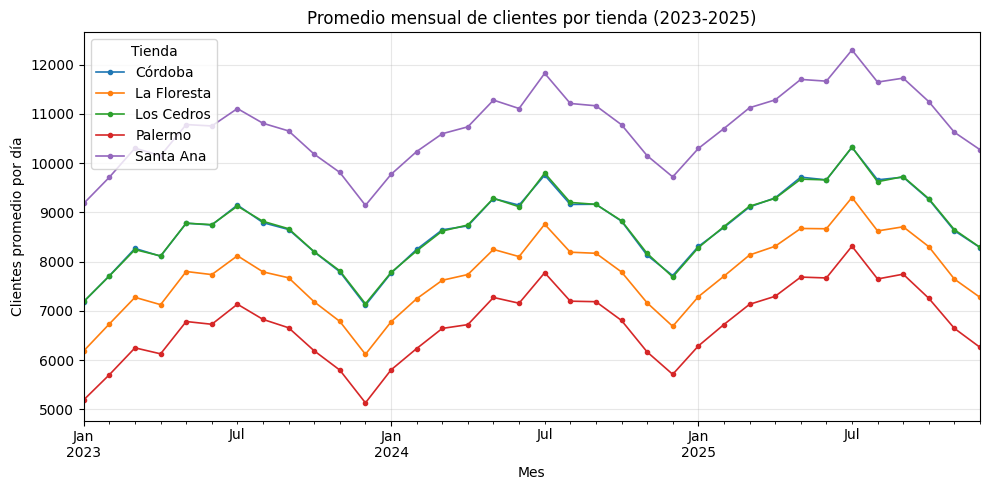

In [5]:
serie = (df.assign(periodo=df['fecha'].dt.to_period('M').dt.to_timestamp())
           .groupby(['periodo', 'tienda'])['clientes'].mean()
           .unstack())

ax = serie.plot(figsize=(10, 5), marker='.', linewidth=1.2)
ax.set_xlabel('Mes')
ax.set_ylabel('Clientes promedio por día')
ax.set_title('Promedio mensual de clientes por tienda (2023-2025)')
ax.legend(title='Tienda', loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Intervalos de confianza para Santa Ana por mes

Con base en los datos generados, determinen intervalos de confianza empíricos para el supermercado 'Santa Ana' en cada mes, para significancias del 95 % y el 99 %.

### Planteo

Para cada mes de cada año estimamos la media de clientes de *Santa Ana*. Como el desvío poblacional no se conoce y se estima de la muestra, el intervalo de confianza para la media usa la distribución $t$ de Student con $n-1$ grados de libertad:

$$
\bar{x} \pm t_{n-1,\,1-\alpha/2}\,\frac{s}{\sqrt{n}} .
$$

Acá $\bar{x}$ es la media del mes, $s$ el desvío muestral y $n$ la cantidad de días observados en ese mes (alrededor de 28 a 31). Con ese $n$ la $t$ ya se acerca a la normal, pero usar $t$ es una aproximación razonable cuando $s$ se estima de los datos. El nivel del 99 % da una banda más ancha que la del 95 %, porque para estar más seguros de cubrir la media hay que abarcar más valores.

In [6]:
santa_ana = df[df['tienda'] == 'Santa Ana']

filas_ic = []
for anio in sorted(santa_ana['anio'].unique()):
    for m in range(1, 13):
        x = santa_ana.loc[(santa_ana['anio'] == anio) & (santa_ana['mes'] == m), 'clientes'].to_numpy()
        n = x.size
        media = x.mean()
        s = x.std(ddof=1)          # desvío estándar muestral; s² es insesgado para σ²
        ee = s / np.sqrt(n)        # error estándar de la media
        for nivel, alpha in [(0.95, 0.05), (0.99, 0.01)]:
            t_crit = st.t.ppf(1 - alpha / 2, df=n - 1)
            filas_ic.append({
                'anio': anio,
                'mes': meses_es[m],
                'nivel': f"{int(nivel*100)}%",
                'n': n,
                'media': media,
                's': s,
                'ee': ee,
                'lim_inf': media - t_crit * ee,  # límite inferior
                'lim_sup': media + t_crit * ee,  # límite superior
            })

ic = pd.DataFrame(filas_ic)
ic.head(10)

,anio,mes,nivel,n,media,s,ee,lim_inf,lim_sup
0,2023,Enero,95%,31,9180.516129,913.670140,164.100001,8845.379216,9515.653042
1,2023,Enero,99%,31,9180.516129,913.670140,164.100001,8729.241838,9631.790420
2,2023,Febrero,95%,28,9712.392857,917.048217,173.305823,9356.798681,10067.987034
3,2023,Febrero,99%,28,9712.392857,917.048217,173.305823,9232.217367,10192.568347
4,2023,Marzo,95%,31,10301.870968,910.798358,163.584214,9967.787433,10635.954503
5,2023,Marzo,99%,31,10301.870968,910.798358,163.584214,9852.015090,10751.726846
6,2023,Abril,95%,30,10149.766667,972.202288,177.499041,9786.740366,10512.792967
7,2023,Abril,99%,30,10149.766667,972.202288,177.499041,9660.510812,10639.022522
8,2023,Mayo,95%,31,10781.516129,918.064880,164.889320,10444.767212,11118.265046
9,2023,Mayo,99%,31,10781.516129,918.064880,164.889320,10328.071215,11234.961043


**Intervalos al 95 %.**

In [7]:
ic95 = (ic[ic['nivel'] == '95%']
        .set_index(['anio', 'mes'])[['n', 'media', 's', 'lim_inf', 'lim_sup']]
        .round(2))
ic95

n     media       s   lim_inf   lim_sup
anio mes                                                 
2023 Enero       31   9180.52  913.67   8845.38   9515.65
     Febrero     28   9712.39  917.05   9356.80  10067.99
     Marzo       31  10301.87  910.80   9967.79  10635.95
     Abril       30  10149.77  972.20   9786.74  10512.79
     Mayo        31  10781.52  918.06  10444.77  11118.27
     Junio       30  10752.83  919.93  10409.33  11096.34
     Julio       31  11106.29  917.69  10769.68  11442.90
     Agosto      31  10807.52  940.13  10462.68  11152.36
     Septiembre  30  10651.93  946.42  10298.53  11005.33
     Octubre     31  10179.52  913.23   9844.54  10514.49
     Noviembre   30   9808.87  950.13   9454.08  10163.65
     Diciembre   31   9140.29  934.26   8797.60   9482.98
2024 Enero       31   9770.00  979.07   9410.87  10129.13
     Febrero     29  10233.97  922.89   9882.92  10585.01
     Marzo       31  10595.52  925.71  10255.96  10935.07
     Abril       30  10735.73  900.90  10399.33  11072.13
     Mayo        31  11278.16  947.12  10930.76  11625.57
     Junio       30  11107.47  963.50  10747.69  11467.24
     Julio       31  11822.06  934.08  11479.44  12164.69
     Agosto      31  11209.77  933.09  10867.51  11552.04
     Septiembre  30  11162.87  940.56  10811.66  11514.08
     Octubre     31  10777.97  954.36  10427.91  11128.03
     Noviembre   30  10149.33  896.22   9814.68  10483.99
     Diciembre   31   9718.87  926.52   9379.02  10058.72
2025 Enero       31  10295.74  948.22   9947.93  10643.55
     Febrero     28  10700.54  929.06  10340.28  11060.79
     Marzo       31  11123.19  936.62  10779.64  11466.75
     Abril       30  11282.20  945.57  10929.12  11635.28
     Mayo        31  11698.16  908.82  11364.80  12031.52
     Junio       30  11662.73  933.33  11314.22  12011.25
     Julio       31  12296.10  953.58  11946.32  12645.87
     Agosto      31  11643.90  933.60  11301.46  11986.35
     Septiembre  30  11724.40  930.93  11376.78  12072.02
     Octubre     31  11247.48  932.88  10905.30  11589.67
     Noviembre   30  10624.50  955.78  10267.61  10981.39
     Diciembre   31  10271.03  949.97   9922.58  10619.49

**Intervalos al 99 %.**

In [8]:
ic99 = (ic[ic['nivel'] == '99%']
        .set_index(['anio', 'mes'])[['n', 'media', 's', 'lim_inf', 'lim_sup']]
        .round(2))
ic99

n     media       s   lim_inf   lim_sup
anio mes                                                 
2023 Enero       31   9180.52  913.67   8729.24   9631.79
     Febrero     28   9712.39  917.05   9232.22  10192.57
     Marzo       31  10301.87  910.80   9852.02  10751.73
     Abril       30  10149.77  972.20   9660.51  10639.02
     Mayo        31  10781.52  918.06  10328.07  11234.96
     Junio       30  10752.83  919.93  10289.88  11215.78
     Julio       31  11106.29  917.69  10653.03  11559.55
     Agosto      31  10807.52  940.13  10343.17  11271.86
     Septiembre  30  10651.93  946.42  10175.65  11128.21
     Octubre     31  10179.52  913.23   9728.46  10630.57
     Noviembre   30   9808.87  950.13   9330.72  10287.02
     Diciembre   31   9140.29  934.26   8678.85   9601.74
2024 Enero       31   9770.00  979.07   9286.42  10253.58
     Febrero     29  10233.97  922.89   9760.41  10707.52
     Marzo       31  10595.52  925.71  10138.30  11052.74
     Abril       30  10735.73  900.90  10282.36  11189.11
     Mayo        31  11278.16  947.12  10810.37  11745.96
     Junio       30  11107.47  963.50  10622.59  11592.34
     Julio       31  11822.06  934.08  11360.71  12283.42
     Agosto      31  11209.77  933.09  10748.91  11670.64
     Septiembre  30  11162.87  940.56  10689.54  11636.20
     Octubre     31  10777.97  954.36  10306.60  11249.34
     Noviembre   30  10149.33  896.22   9698.31  10600.35
     Diciembre   31   9718.87  926.52   9261.25  10176.49
2025 Enero       31  10295.74  948.22   9827.40  10764.08
     Febrero     28  10700.54  929.06  10214.07  11187.00
     Marzo       31  11123.19  936.62  10660.58  11585.80
     Abril       30  11282.20  945.57  10806.35  11758.05
     Mayo        31  11698.16  908.82  11249.28  12147.04
     Junio       30  11662.73  933.33  11193.04  12132.43
     Julio       31  12296.10  953.58  11825.11  12767.08
     Agosto      31  11643.90  933.60  11182.79  12105.02
     Septiembre  30  11724.40  930.93  11255.91  12192.89
     Octubre     31  11247.48  932.88  10786.72  11708.25
     Noviembre   30  10624.50  955.78  10143.51  11105.49
     Diciembre   31  10271.03  949.97   9801.83  10740.24

El gráfico compara las dos bandas mes a mes a lo largo de los tres años. Cada punto es la media estimada de un mes y las barras son los intervalos al 95 % y al 99 %. La banda del 99 % siempre contiene a la del 95 %.

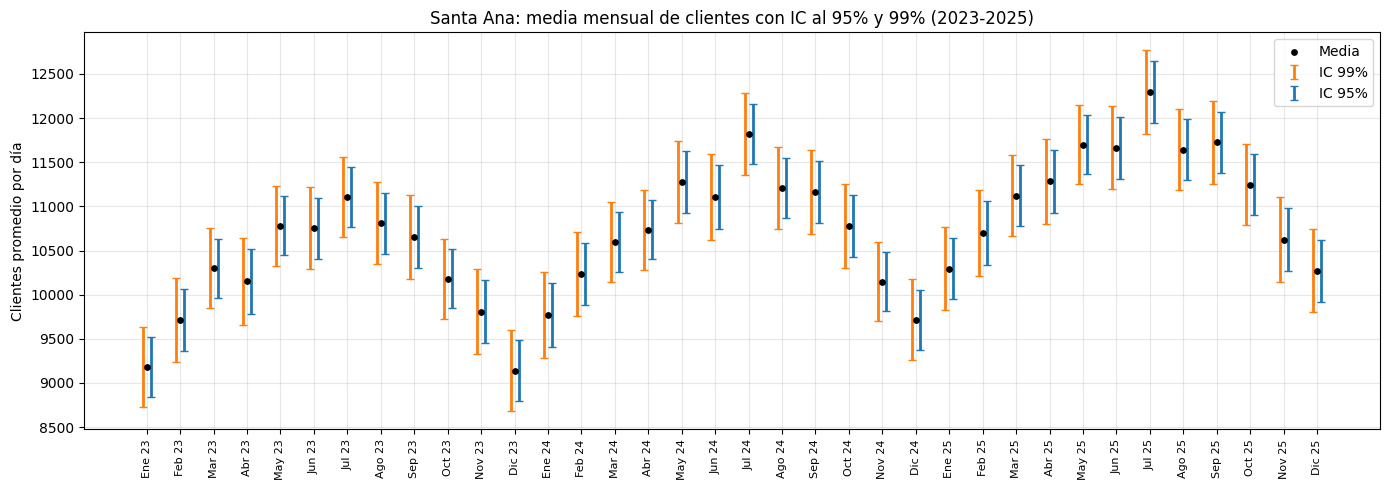

In [9]:
abrev = {n: n[:3] for n in meses_es.values()}
anios = sorted(ic['anio'].unique())
orden = [(a, meses_es[m]) for a in anios for m in range(1, 13)]
etiquetas = [f"{abrev[mes]} {str(a)[2:]}" for a, mes in orden]

m95 = ic[ic['nivel'] == '95%'].set_index(['anio', 'mes']).loc[orden]
m99 = ic[ic['nivel'] == '99%'].set_index(['anio', 'mes']).loc[orden]
xpos = np.arange(len(orden))

fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(xpos - 0.12, m99['media'],
            yerr=[m99['media'] - m99['lim_inf'], m99['lim_sup'] - m99['media']],
            fmt='none', ecolor='tab:orange', capsize=3, elinewidth=2, label='IC 99%')
ax.errorbar(xpos + 0.12, m95['media'],
            yerr=[m95['media'] - m95['lim_inf'], m95['lim_sup'] - m95['media']],
            fmt='none', ecolor='tab:blue', capsize=3, elinewidth=2, label='IC 95%')
ax.scatter(xpos, m95['media'], color='black', zorder=3, s=15, label='Media')
ax.set_xticks(xpos)
ax.set_xticklabels(etiquetas, rotation=90, ha='center', fontsize=8)
ax.set_ylabel('Clientes promedio por día')
ax.set_title('Santa Ana: media mensual de clientes con IC al 95% y 99% (2023-2025)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La media mensual sigue el efecto estacional cargado en la simulación: sube hacia julio y baja en los meses de verano. Los intervalos son angostos en relación con el nivel de clientes, porque incluso con unos 30 días por mes el error estándar de la media es chico. En todos los meses la banda del 99 % es más ancha que la del 95 %, como corresponde a un mayor nivel de confianza.

## 3. ANOVA entre las cinco tiendas

De igual manera, realicen pruebas ANOVA para determinar si los clientes esperados de todas las tiendas son iguales o no, con significancia del 95 %.

### Planteo

El ANOVA de un factor compara las medias de varios grupos a la vez. Las hipótesis son:

$$
H_0:\ \mu_1 = \mu_2 = \mu_3 = \mu_4 = \mu_5
\qquad\text{contra}\qquad
H_1:\ \text{al menos una media difiere.}
$$

El estadístico $F$ es el cociente entre la variabilidad entre tiendas y la variabilidad dentro de cada tienda. Si las medias fueran iguales, $F$ estaría cerca de 1. Un $F$ grande, con $p$-valor menor a $0.05$, lleva a rechazar $H_0$.

In [10]:
grupos = [df.loc[df['tienda'] == t, 'clientes'].to_numpy() for t in efecto_tienda]

F, p_anova = st.f_oneway(*grupos)
print(f"Estadístico F : {F:.2f}")
print(f"p-valor       : {p_anova:.3e}")
print(f"Decisión (alpha=0.05): {'se rechaza H0' if p_anova < 0.05 else 'no se rechaza H0'}")

Estadístico F : 1723.50
p-valor       : 0.000e+00
Decisión (alpha=0.05): se rechaza H0


El $p$-valor es prácticamente cero, muy por debajo de $0.05$, así que se rechaza $H_0$: las tiendas no reciben en promedio la misma cantidad de clientes. El ANOVA dice que hay diferencias, pero no cuáles. Para ubicarlas corremos una prueba post hoc de Tukey, que compara todos los pares de tiendas controlando el error por comparaciones múltiples.

In [11]:
tukey = pairwise_tukeyhsd(df['clientes'].to_numpy(),
                          df['tienda'].to_numpy(), alpha=0.05)
print(tukey.summary())

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1      group2    meandiff  p-adj   lower      upper    reject
---------------------------------------------------------------------
    Córdoba La Floresta -1002.0283   0.0 -1139.8931  -864.1635   True
    Córdoba  Los Cedros     2.2208   1.0   -135.644   140.0856  False
    Córdoba     Palermo -1996.5876   0.0 -2134.4524 -1858.7228   True
    Córdoba   Santa Ana  2001.6569   0.0  1863.7921  2139.5218   True
La Floresta  Los Cedros  1004.2491   0.0   866.3843  1142.1139   True
La Floresta     Palermo  -994.5593   0.0 -1132.4241  -856.6945   True
La Floresta   Santa Ana  3003.6852   0.0  2865.8204  3141.5501   True
 Los Cedros     Palermo -1998.8084   0.0 -2136.6732 -1860.9436   True
 Los Cedros   Santa Ana  1999.4361   0.0  1861.5713   2137.301   True
    Palermo   Santa Ana  3998.2445   0.0  3860.3797  4136.1094   True
---------------------------------------------------------------------


La columna `reject` en `True` para todos los pares indica que cada tienda difiere de las demás de forma significativa, salvo donde los efectos coinciden. *Los Cedros* y *Córdoba* tienen el mismo efecto de tienda (3000), así que la diferencia entre ese par es la única que puede no resultar significativa. El resto de las comparaciones confirma el orden esperado de niveles.

## 4. Prueba de hipótesis entre la tienda de mayor y menor promedio

Finalmente, identifiquen la tienda con mayor promedio y la tienda con menor promedio de clientes y realicen una prueba de hipótesis para determinar si la diferencia entre ellas es distinta de cero o no. Verifiquen si las tiendas identificadas corresponden a las tiendas con mayores y menores efectos.

### Planteo

Primero ordenamos las tiendas por su promedio simulado de clientes. Sobre las dos extremas planteamos una prueba de diferencia de medias para dos muestras independientes:

$$
H_0:\ \mu_{\max} - \mu_{\min} = 0
\qquad\text{contra}\qquad
H_1:\ \mu_{\max} - \mu_{\min} \neq 0 .
$$

Usamos el test $t$ de Welch (`equal_var=False`), que no supone varianzas iguales entre las dos tiendas. Es la opción prudente acá, porque al ser un proceso de Poisson la varianza crece con la media y los dos grupos tienen niveles distintos.

In [12]:
medias = df.groupby('tienda')['clientes'].mean().sort_values()
print("Promedio de clientes por tienda (ascendente):")
print(medias.round(1))

tienda_min = medias.index[0]
tienda_max = medias.index[-1]
print(f"\nMenor promedio: {tienda_min}")
print(f"Mayor promedio: {tienda_max}")

Promedio de clientes por tienda (ascendente):
tienda
Palermo         6718.3
La Floresta     7712.9
Córdoba         8714.9
Los Cedros      8717.1
Santa Ana      10716.5
Name: clientes, dtype: float64

Menor promedio: Palermo
Mayor promedio: Santa Ana


In [13]:
a = df.loc[df['tienda'] == tienda_max, 'clientes'].to_numpy()
b = df.loc[df['tienda'] == tienda_min, 'clientes'].to_numpy()

t_stat, p_val = st.ttest_ind(a, b, equal_var=False)

print(f"Diferencia de medias ({tienda_max} - {tienda_min}): {a.mean() - b.mean():.1f}")
print(f"Estadístico t : {t_stat:.2f}")
print(f"p-valor       : {p_val:.3e}")
print(f"Decisión (alpha=0.05): {'se rechaza H0, la diferencia es distinta de cero' if p_val < 0.05 else 'no se rechaza H0'}")

Diferencia de medias (Santa Ana - Palermo): 3998.2
Estadístico t : 79.20
p-valor       : 0.000e+00
Decisión (alpha=0.05): se rechaza H0, la diferencia es distinta de cero


### Verificación contra los efectos por tienda

Comparamos las tiendas que salieron de los datos con las que tienen el mayor y el menor efecto en la simulación.

In [14]:
efmax = max(efecto_tienda, key=efecto_tienda.get)
efmin = min(efecto_tienda, key=efecto_tienda.get)

print(f"Mayor efecto: {efmax} ({efecto_tienda[efmax]})")
print(f"Menor efecto: {efmin} ({efecto_tienda[efmin]})")
print()
print(f"Mayor promedio observado: {tienda_max} -> coincide: {tienda_max == efmax}")
print(f"Menor promedio observado: {tienda_min} -> coincide: {tienda_min == efmin}")

Mayor efecto: Santa Ana (5000)
Menor efecto: Palermo (1000)

Mayor promedio observado: Santa Ana -> coincide: True
Menor promedio observado: Palermo -> coincide: True


El $p$-valor es prácticamente cero, así que se rechaza $H_0$: la diferencia de clientes entre la tienda de mayor y la de menor promedio es distinta de cero. Las tiendas identificadas son *Santa Ana* (mayor promedio) y *Palermo* (menor promedio), que coinciden con las de mayor efecto (5000) y menor efecto (1000) de la simulación. Esto era lo esperable, porque el efecto de tienda es el único término del modelo que cambia entre tiendas: los efectos de año, mes y día son comunes a todas, de modo que el orden de los promedios refleja directamente el orden de los efectos por tienda.

## Conclusiones

**Planteamiento.** Don Francisco tenía dos preguntas: cuántos clientes recibe *Santa Ana* mes a mes, y si las cinco tiendas reciben en promedio la misma cantidad de gente. Para responderlas simulamos los clientes diarios y aplicamos tres herramientas: intervalos de confianza, ANOVA y una prueba de diferencia de medias.

**Procesamiento.** Simulamos los clientes diarios de las cinco tiendas entre 2023 y 2025 con un modelo de Poisson. Su parámetro suma cuatro efectos: año, mes, día de la semana y tienda. Con esos datos calculamos los intervalos $t$ para la media mensual de *Santa Ana* (al 95 % y al 99 %), el ANOVA con su post hoc de Tukey, y el test de Welch entre la tienda de mayor y la de menor promedio.

**Análisis.** La tienda de mayor promedio es *Santa Ana* y la de menor es *Palermo*, justo las de mayor y menor efecto. Esto tiene sentido: el efecto de tienda es lo único que cambia entre locales, porque los efectos de año, mes y día son iguales para todas. Por eso el orden de los promedios copia el orden de los efectos. Para Don Francisco la lectura es directa: las tiendas no rinden parejo. *Palermo* es la de menor afluencia y la que más atención necesita; *Santa Ana* es la de mayor movimiento.

**Resultados.** Los intervalos de *Santa Ana* siguen la estacionalidad del modelo: suben en invierno y bajan en verano. Son angostos porque cada mes reúne unos 30 días, y la banda del 99 % siempre contiene a la del 95 %. El ANOVA da un $p$ casi nulo, así que las tiendas no reciben la misma cantidad de clientes. Tukey separa a todas las tiendas entre sí, salvo *Los Cedros* y *Córdoba*, que comparten efecto. El test entre extremos confirma que *Santa Ana* y *Palermo* difieren.